In [1]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [2]:
import pandas as pd

In [3]:
root = '/home/berens/bep973/ifeoma_home/data/NAKO/NAKO_macula'
image_folder = f'{root}/NAKO_macula'
all_data = f'{root}/nako_reports_macula_and_grade.csv'
vanilla_train = pd.read_csv(all_data)

In [4]:
vanilla_train.head()

,original_image_name,original_img_size,new_image_name,new_image_size,KeyError,Gradable,Confidence
0,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/130822.jpg,"(256, 256)",OK,Ungradeable,0.118215
1,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/113978.jpg,"(256, 256)",OK,Ungradeable,0.193996
2,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/112480.jpg,"(256, 256)",OK,Gradeable,0.232728
3,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/105569.jpg,"(256, 256)",OK,Ungradeable,0.135763
4,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftnasal/137913.jpg,"(256, 256)",OK,Ungradeable,0.083499


In [20]:
vanilla_train['ID'] = vanilla_train['new_image_name'].apply(lambda x: int(x.split('/')[-1].split('.')[0]))
vanilla_train.tail(1)

,original_image_name,original_img_size,new_image_name,new_image_size,KeyError,Gradable,Confidence,ID
153133,/gpfs01/berens/data/data/NAKO/nako_decrypted/n...,"(512, 512)",C_rt_leftcentral/138663.jpg,"(256, 256)",OK,Ungradeable,0.164297,138663


In [23]:
vanilla_train_grp = vanilla_train.groupby('ID').agg(list).reset_index(drop = False)
vanilla_train_grp.head(2)

,ID,original_image_name,original_img_size,new_image_name,new_image_size,KeyError,Gradable,Confidence
0,100000,[/gpfs01/berens/data/data/NAKO/nako_decrypted/...,"[(512, 512), (512, 512), (512, 512), (512, 512)]","[C_rt_leftnasal/100000.jpg, C_rt_rightcentral/...","[(256, 256), (256, 256), (256, 256), (256, 256)]","[OK, OK, OK, OK]","[Ungradeable, Ungradeable, Ungradeable, Ungrad...","[0.15141208, 0.14005701, 0.13337037, 0.1884981]"
1,100001,[/gpfs01/berens/data/data/NAKO/nako_decrypted/...,"[(512, 512), (512, 512), (512, 512), (512, 512)]","[C_rt_leftnasal/100001.jpg, C_rt_rightcentral/...","[(256, 256), (256, 256), (256, 256), (256, 256)]","[OK, OK, OK, OK]","[Ungradeable, Gradeable, Ungradeable, Gradeable]","[0.12907901, 0.26003593, 0.14061901, 0.2532641]"


In [29]:
vanilla_train.shape, vanilla_train_grp.shape

((153134, 8), (45247, 8))

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

In [15]:
all_images = list(vanilla_train['new_image_name'].values)
# all_images

In [11]:
img1 = Image.open(os.path.join(image_folder,vanilla_train.iloc[0, 2]))
img1.size

(256, 256)

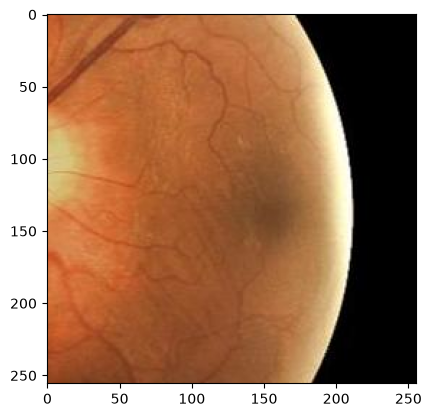

In [16]:
plt.imshow(img1)
plt.show()

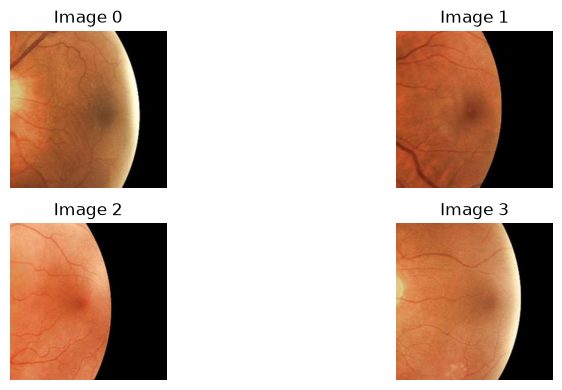

In [19]:
fig, ax = plt.subplots(2, 2, figsize = (10, 4))
for i in range(2):
    for j in range(2):
        idx = i *2 + j
        img_name = os.path.join(image_folder, all_images[idx])
        img = Image.open(img_name)
        ax[i, j].imshow(img)
        ax[i, j].axis('off')
        ax[i, j].set_title(f"Image {idx}")
plt.tight_layout()
plt.show()

In [25]:
import random
import numpy as np

In [34]:
def display_nako(train, image_folder, prefix='', 
                 n_samples = 5, n_images_per_id = 2, original_images = False):
    images_to_view = {}
    random_ids = random.sample(list(range(train.shape[0])), n_samples)
    print(random_ids)
    for i in random_ids:
        for m in range(2):
            row = train.iloc[i]
            id = row['ID']
            image_list = row['new_image_name']
            len_images = min(10, len(image_list))
            for j in range(len_images):
                image_name = image_list[j]
                if original_images:
                    image_name = image_name.split('C_')[-1]
                    image_folder = '/home/berens/bep973/ifeoma_home/data/NAKO/images_lowres/224'


                # label = row['diagnosis_amd_grade'][j]
                # image_eye = row['image_eye'][j]
                # visit_number = row['visit_number'][j]
                # image_side = row['image_side'][j]
                image  = Image.open(os.path.join( image_folder, f"{image_name}")).convert("RGB")

                if id not in images_to_view:
                    images_to_view[id] = {'images': [], 'visit_number': [], 'image_eye': [], 'label': [], 'image_side': []}
                if len(images_to_view[id]['images']) < n_images_per_id:
                    images_to_view[id]['images'].append(image)
                    # images_to_view[id]['visit_number'].append(visit_number)
                    # images_to_view[id]['image_eye'].append(image_eye)
                    # images_to_view[id]['label'].append(label)
                    # images_to_view[id]['image_side'].append(image_side)



    fig, axs = plt.subplots( n_samples, n_images_per_id+1, figsize=(n_images_per_id * 2, 3))
    for t, (id, data) in enumerate(images_to_view.items()):
        axs[t, 0].text(0,0.3, id)
        axs[t, 0].axis('off')
        n_images_in_id = len(data['images'])
        
        for k in range(n_images_in_id): 
            
            image = data['images'][k] 
            # image_eye = data['image_eye'][k]
            # amount_ = data['visit_number'][k]
            # label = data["label"][k]
            # image_side = data["image_side"][k]

            image_arr = np.array(image)
            title = 'x'
            # title = f"{image_eye} {image_side} V_no: {amount_} AMD: {label}"
            axs[t, k+1].imshow(image_arr)
            axs[t, k+1].set_title(title, fontsize = 6)
        
            axs[t, k+1].axis('off')

[18888, 843, 12537, 41395, 28948]


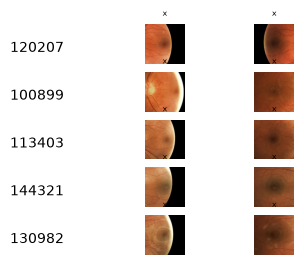

In [35]:
display_nako(vanilla_train_grp, image_folder, prefix='', n_samples = 5, n_images_per_id = 2)

[28323, 42570, 6546, 3258, 24911]


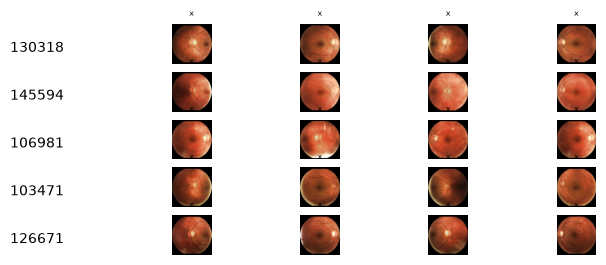

In [37]:
display_nako(vanilla_train_grp, image_folder, prefix='', 
             n_samples = 5, n_images_per_id = 4, original_images=True)